# EDA — VisDrone-DET2019

Detección de objetos desde perspectiva aérea  
Miguel Alejandro Flores Sotelo · Sergio de Jesús Castillo Molano

## Objetivo
Caracterizar el dataset VisDrone-DET2019 **antes de entrenar** cualquier modelo.
El EDA nos dirá exactamente qué estrategias de augmentación son necesarias.

## Contenido
1. Parseo de anotaciones → DataFrame
2. Distribución de clases
3. Distribución de tamaños de bounding boxes
4. Distribución de aspect ratio
5. Densidad de objetos por imagen
6. Distribución de resoluciones de imagen
7. Visualización de imágenes con bboxes
8. Análisis de truncación y oclusión

---

## 1. Parseo de anotaciones -> DataFrame

### Formato original de VisDrone
Cada archivo `.txt` tiene una línea por objeto detectado:
```
bbox_left, bbox_top, bbox_width, bbox_height, score, category, truncation, occlusion
```
- **score = 0** → región a ignorar (la filtramos)
- **category** → 0=ignorar, 1=pedestrian, ..., 10=motor (1-indexado; lo convertimos a 0-indexado)
- **truncation** → 0=completo, 1=parcialmente fuera del encuadre
- **occlusion** → 0=sin oclusión, 1=oclusión parcial, 2=oclusión pesada

In [2]:
#Imports
import yaml
import pandas as pd
from pathlib import Path

In [3]:
# Cargar configuración desde configs/visdrone.yaml
PROJECT_ROOT = Path("..")  # notebooks/ está un nivel abajo de la raiz (para llegar a la raiz del proyecto)
config_path  = PROJECT_ROOT / "configs" / "visdrone.yaml" #cosntruye la ruta al YAML

with open(config_path) as f:
    cfg = yaml.safe_load(f) #lee el yaml y lo convierte en un diccionario de python

DATASET_ROOT = PROJECT_ROOT / cfg["path"]
LABELS_TRAIN = DATASET_ROOT / cfg["labels"]["train"]
CLASS_NAMES  = cfg["names"]   # dict {0: 'pedestrian', 1: 'people', ...}

print(f"Raíz del dataset : {DATASET_ROOT.resolve()}") # .resolve() Obtiene la ruta completa y limpia desde la raíz del sistema.
print(f"Labels train     : {LABELS_TRAIN.resolve()}")
print(f"Clases           : {CLASS_NAMES}")

Raíz del dataset : /home/magicmike/TT-deteccion-aerea/data/visdrone
Labels train     : /home/magicmike/TT-deteccion-aerea/data/visdrone/labels/train
Clases           : {0: 'pedestrian', 1: 'people', 2: 'bicycle', 3: 'car', 4: 'van', 5: 'truck', 6: 'tricycle', 7: 'awning-tricycle', 8: 'bus', 9: 'motor'}


In [4]:
# Parsear todas las anotaciones del split train 
records = [] #lista de detecciones como diccionario
label_files = sorted(LABELS_TRAIN.glob("*.txt")) #busca todos los archivos .txt en dicha carpeta y se ordena alfabeticamente para que las detecciones s eporcesen en mismo orden (reproducibilidad)

for txt_file in label_files: #recorremos cada archivo de labels
    img_name = txt_file.stem  # nombre de archivo sin extensión (.txt)
    with open(txt_file) as f:
        for line in f: #abre el archivo y recorremos cada linea
            parts = line.strip().split(",") #quitamos espascioes en blanco , saltos de linea y lo dividimos por ,
            if len(parts) != 8: # filtro de seguirdad, cada deteccion debe tener 8 valores sino (esta corrupta)
                continue
            x, y, w, h, score, cat_id, trunc, occl = [int(p) for p in parts] #convertimos de string a int y le asignamos su variable

            # Filtrar regiones ignoradas (score=0) y categoría inválida (cat_id=0)
            if score == 0 or cat_id == 0:
                continue

            # VisDrone usa category 1-indexed -> convierte a 0-indexed
            cat_id_0 = cat_id - 1

            records.append({
                "image"       : img_name,
                "x"           : x,
                "y"           : y,
                "w"           : w,
                "h"           : h,
                "area"        : w * h, #numero d epixeles que ocupa el bounding box
                "aspect_ratio": round(w / h, 3) if h > 0 else 0, #que tan ancho es el objeto en relacion a su altura
                "cat_id"      : cat_id_0,
                "class"       : CLASS_NAMES[cat_id_0],
                "truncation"  : trunc,
                "occlusion"   : occl,
            })

df = pd.DataFrame(records) #convertimos la lista de diccionarios en un dataframe

print(f"Total de detecciones válidas (train) : {len(df):,}") #total de detecciones 
print(f"Imágenes únicas                      : {df['image'].nunique():,}") #total de imagene sunicas
print(f"Clases presentes                     : {df['class'].nunique()}") #total de clases unicas
print()
df.head(10)

Total de detecciones válidas (train) : 343,171
Imágenes únicas                      : 6,470
Clases presentes                     : 10



,image,x,y,w,h,area,aspect_ratio,cat_id,class,truncation,occlusion
0,0000002_00005_d_0000014,708,471,74,33,2442,2.242,3,car,0,1
1,0000002_00005_d_0000014,639,425,61,46,2806,1.326,3,car,0,0
2,0000002_00005_d_0000014,594,399,64,51,3264,1.255,3,car,0,0
3,0000002_00005_d_0000014,562,390,61,38,2318,1.605,3,car,0,0
4,0000002_00005_d_0000014,540,372,65,33,2145,1.970,3,car,0,1
5,0000002_00005_d_0000014,514,333,68,35,2380,1.943,3,car,0,0
6,0000002_00005_d_0000014,501,317,64,31,1984,2.065,3,car,0,1
7,0000002_00005_d_0000014,501,299,45,28,1260,1.607,3,car,0,1
8,0000002_00005_d_0000014,489,284,48,27,1296,1.778,3,car,0,1
9,0000002_00005_d_0000014,463,262,48,29,1392,1.655,3,car,0,0


## 2. Distribución de clases

Contamos cuántas detecciones hay de cada clase para confirmar el **desbalance severo**. Este análisis justifica las estrategias de augmentación dirigidas a clases minoritarias (copy-paste, class weighting, mosaic).

### Métricas a calcular
- Número total de detecciones por clase
- Porcentaje de cada clase respecto al total
- Clase mayoritaria y minoritaria
- **Ratio de desbalance** = mayoritaria / minoritaria (un valor > 10x se considera severo)

In [5]:
#Conteo de detecciones por clase
import matplotlib.pyplot as plt

#Contar detecciones por clase
class_counts=df["class"].value_counts()

#Calcular porcentajes
class_pct=(class_counts/len(df)*100).round(2)

#Tabla de resumen
class_summary=pd.DataFrame({
    "detecciones":class_counts,
    "porcentajes":class_pct
})

#Calcular ratio de desbalance
ratio=class_counts.max()/class_counts.min()

print(f"Total de detecciones: {len(df):,}")
print(f"Clase mayoritaria: {class_counts.idxmax()} ({class_counts.max():,})")
print(f"Clase minoritaria: {class_counts.idxmin()} ({class_counts.min():,})")
print(f"Ratio de desbalance: {ratio:.1f}x")
print()
class_summary


Total de detecciones: 343,171
Clase mayoritaria: car (144,865)
Clase minoritaria: awning-tricycle (3,243)
Ratio de desbalance: 44.7x



,detecciones,porcentajes
class,,
car,144865,42.21
pedestrian,79335,23.12
motor,29642,8.64
people,27059,7.88
van,24950,7.27
truck,12871,3.75
bicycle,10477,3.05
bus,5926,1.73
tricycle,4803,1.40


### Visualización
Gráfica de barras ordenada de mayor a menor para identificar visualmente qué clases dominan y cuáles son minoritarias.

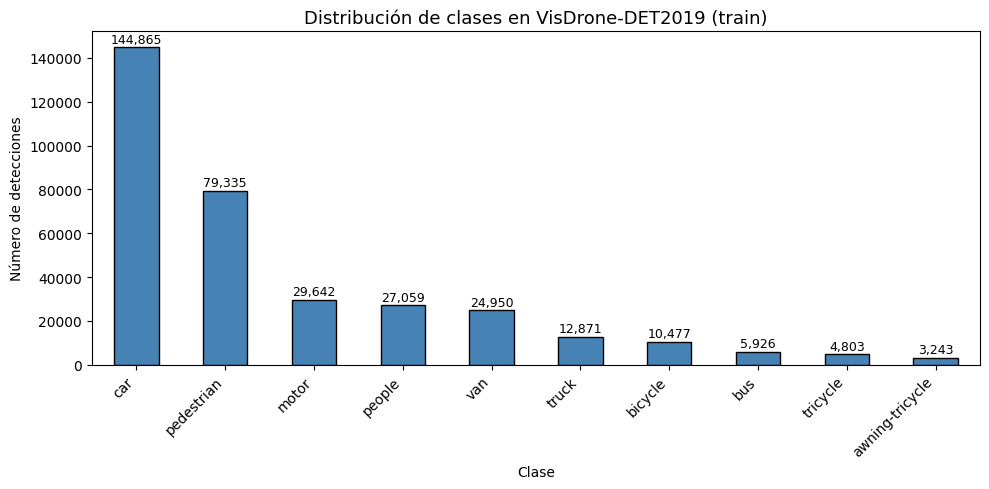

In [6]:
#Gráfica de barras: distribución de clases
fig,ax=plt.subplots(figsize=(10,5))

class_counts.plot(kind="bar",ax=ax, color="steelblue",edgecolor="black")

ax.set_title("Distribución de clases en VisDrone-DET2019 (train)", fontsize=13)
ax.set_xlabel("Clase")
ax.set_ylabel("Número de detecciones")
ax.set_xticklabels(class_counts.index,rotation=45,ha="right")

#Se agrga el valor encima de cada barra
for i,v in enumerate(class_counts.values):
    ax.text(i,v+2000,f"{v:,}",ha="center",fontsize=9)

plt.tight_layout()

#Guardamos la figura
output_dir = PROJECT_ROOT /"results" /"figures" /"eda"
output_dir.mkdir(parents=True,exist_ok=True)
plt.savefig(output_dir/"01_distribucion_clases.png",dpi=150,bbox_inches="tight")

#Guardamos la tabla
tables_dir = PROJECT_ROOT / "results" / "tables" / "eda"
tables_dir.mkdir(parents=True, exist_ok=True)
class_summary.to_csv(tables_dir / "01_distribucion_clases.csv")

plt.show()

## 3. Distribución de tamaños de bounding boxes

Caracterizamos el tamaño de los objetos para confirmar la predominancia de **small objects**, uno de los retos centrales del dominio aéreo según el protocolo.

### Criterio COCO (estándar internacional)
- **Small**  : área < 32² px (1,024 px²)
- **Medium** : 32² ≤ área < 96² px (1,024 a 9,216 px²)
- **Large**  : área ≥ 96² px (9,216 px²)

### Métricas a calcular
- Estadísticas descriptivas (media, mediana, percentiles) del área
- Porcentaje de objetos en cada categoría COCO
- Distribución del área por clase

In [7]:
#Estadisticas descriptivas del área de los bbboxes

print("Estadísticas del área (px^2): ")
print(df["area"].describe().round(2))
print()
print(f"Área mínima:{df['area'].min():,}px^2")
print(f"Área máxima:{df['area'].max():,}px^2")
print(f"Mediana:{df['area'].median():,.0f}px^2")
print(f"Media:{df['area'].mean():,.0f}px^2")

Estadísticas del área (px^2): 
count    343171.00
mean       2447.99
std        6598.22
min           0.00
25%         243.00
50%         680.00
75%        2025.00
max      328640.00
Name: area, dtype: float64

Área mínima:0px^2
Área máxima:328,640px^2
Mediana:680px^2
Media:2,448px^2


### Clasificación COCO
Etiquetamos cada detección según los umbrales COCO para cuantificar qué proporción del dataset son small, medium o large objects.

In [8]:
#Clasificar cada bbox según criterio COCO
def coco_size(area):
    if area<32**2:
        return "small"
    if area<96**2:
        return "medium"
    else:
        return "large"
    
df["coco_size"]=df["area"].apply(coco_size)

#Conteo y porcentaje
size_counts=df["coco_size"].value_counts()
size_pct=(size_counts/len(df)*100).round(2)

size_summary=pd.DataFrame({
    "detecciones":size_counts,
    "porcentaje":size_pct
})

print("Distribución por categoría COCO:")
print(size_summary)


Distribución por categoría COCO:
           detecciones  porcentaje
coco_size                         
small           207520       60.47
medium          116675       34.00
large            18976        5.53


### Visualización 1: Distribución global del área
Histograma con escala logarítmica en X para ver mejor la distribución, ya que las áreas varían desde ~1 px² hasta cientos de miles.

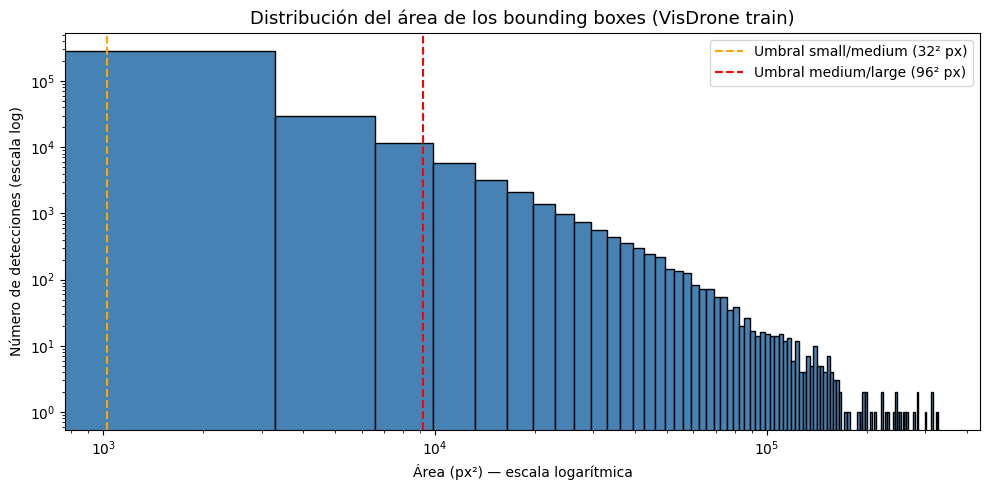

In [9]:
#Histograma del aerea (escala log)
fig,ax=plt.subplots(figsize=(10,5))

ax.hist(df["area"],bins=100,color="steelblue",edgecolor="black",log=True)

ax.axvline(32**2,color="orange",linestyle="--",label="Umbral small/medium (32² px)")
ax.axvline(96**2,color="red",linestyle="--",label="Umbral medium/large (96² px)")

ax.set_xscale("log")
ax.set_title("Distribución del área de los bounding boxes (VisDrone train)", fontsize=13)
ax.set_xlabel("Área (px²) — escala logarítmica")
ax.set_ylabel("Número de detecciones (escala log)")
ax.legend()

plt.tight_layout()
plt.savefig(output_dir / "02_distribucion_areas.png", dpi=150, bbox_inches="tight")
plt.show()


### Visualización 2: Categorías COCO en gráfica de pastel
Para visualizar de forma directa qué proporción del dataset son small, medium o large.

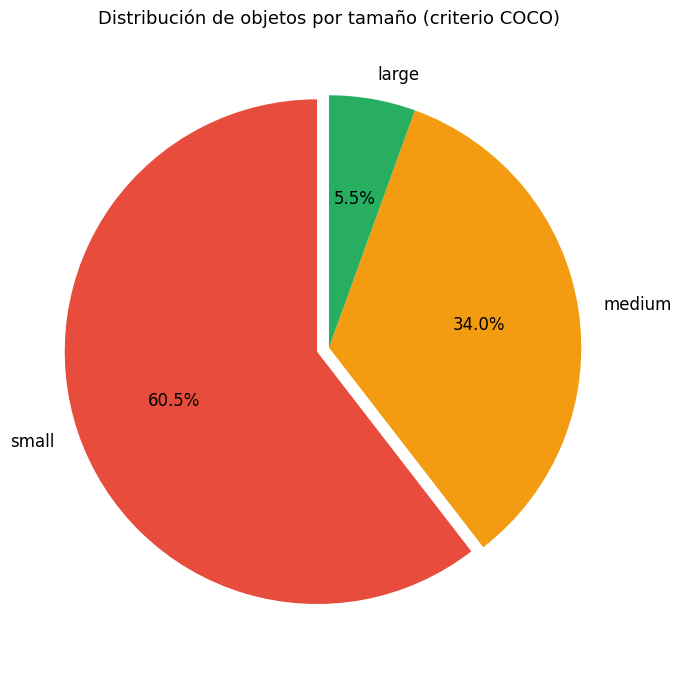

In [10]:
#Grafica de pastel: small/medium/large
fig,ax=plt.subplots(figsize=(7,7))

colors = {"small":"#e74c3c", "medium":"#f39c12", "large":"#27ae60"}

#Ordenar de forma consistente
order=["small","medium","large"]
counts_ordered=size_counts.reindex(order) #ordenar por orden de "order lista"
colors_ordered=[colors[k] for k in order] #obtenemos los colores correspondientes

ax.pie(
    counts_ordered,
    labels=order,
    autopct="%1.1f%%",
    colors=colors_ordered,
    startangle=90,
    explode=(0.05, 0, 0),
    textprops={"fontsize": 12}
)
ax.set_title("Distribución de objetos por tamaño (criterio COCO)", fontsize=13)

plt.tight_layout()
plt.savefig(output_dir / "03_categorias_coco.png", dpi=150, bbox_inches="tight")
plt.show()

### Visualización 3: Área por clase (boxplot)
Compara el tamaño típico de cada clase.

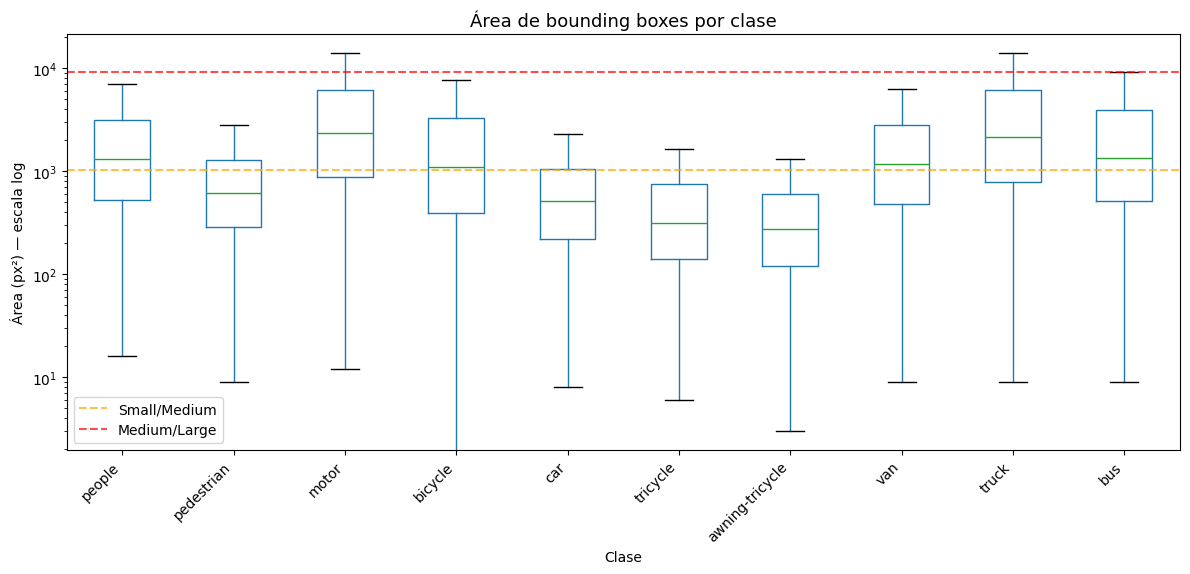

In [11]:
#Boxplot del área por clase
fog,ax=plt.subplots(figsize=(12,6))

#Ordenar por mediana (menor a mayor)

class_order=df.groupby("class")["area"].median().sort_values().index #ordena por clase, extrae solo la columna area, les aplica la mediana , ordena de menor a mayor y con .index obtiene los indices (nombres de clases)

df.boxplot(
    column="area",
    by="class",
    ax=ax,
    grid=False,
    showfliers=False,        # ocultar outliers para mejor visualización
    positions=range(len(class_order)),
)

# Reordenar las etiquetas
ax.set_xticklabels(class_order, rotation=45, ha="right")

# Líneas COCO de referencia
ax.axhline(32**2,color="orange",linestyle="--",alpha=0.7,label="Small/Medium")
ax.axhline(96**2,color="red",linestyle="--",alpha=0.7,label="Medium/Large")

ax.set_yscale("log")
ax.set_title("Área de bounding boxes por clase", fontsize=13)
ax.set_xlabel("Clase")
ax.set_ylabel("Área (px²) — escala log")
ax.legend()
plt.suptitle("")  # quitar título automático de pandas

plt.tight_layout()
plt.savefig(output_dir / "04_area_por_clase.png", dpi=150, bbox_inches="tight")
plt.show()


### Tabla resumen: porcentaje small/medium/large por clase
Para identificar qué clases son las más afectadas por el problema de small objects.

In [12]:
#Tabla cruzada : clave vs categoria COCO
size_per_class=pd.crosstab(df["class"],df["coco_size"],normalize="index")*100 #normaliza conforme a las filas (index=small,medium,large)
size_per_class=size_per_class.round(2)
size_per_class=size_per_class[["small","medium","large"]] #reordenar

#Ordenar por % de small (de mayor a menor)
size_per_class=size_per_class.sort_values("small",ascending=False)

print("Porcentaje de objetos por tamaño (en cada clase):")
size_per_class



Porcentaje de objetos por tamaño (en cada clase):


coco_size,small,medium,large
class,,,
people,86.87,12.77,0.37
pedestrian,82.22,17.39,0.39
motor,74.10,25.00,0.90
bicycle,67.74,31.05,1.21
car,48.18,43.58,8.24
tricycle,45.35,50.28,4.37
van,43.03,46.23,10.73
awning-tricycle,42.09,52.17,5.74
truck,30.95,52.23,16.82


In [13]:
#Exportamos tablas a csv
tables_dir=PROJECT_ROOT / "results" / "tables" / "eda"
tables_dir.mkdir(parents=True, exist_ok=True)

size_summary.to_csv(tables_dir / "02_categorias_coco.csv")
size_per_class.to_csv(tables_dir / "03_tamano_por_clase.csv")


## 4. Distribución de Aspect Ratio

El **aspect ratio** (w ÷ h) describe la forma de los bounding boxes.
En perspectiva aérea los objetos se ven desde arriba, por lo que sus
proporciones difieren significativamente de datasets terrestres como COCO.

Este análisis justifica la necesidad de recalcular los **anchors** de YOLO
específicamente para VisDrone en lugar de usar los valores por defecto
entrenados sobre imágenes terrestres.

### Clasificación por forma
- **Vertical**   : aspect_ratio < 0.75  → más alto que ancho (ej. peatón de pie)
- **Cuadrado**   : 0.75 ≤ aspect_ratio ≤ 1.33 → proporción balanceada
- **Horizontal** : aspect_ratio > 1.33  → más ancho que alto (ej. coche visto desde arriba)

In [14]:
#Disribución de Aspect Ratio

#Estadisticas descriptivas
print("Estadisticas del aspect ratio (w/h)")
print(df["aspect_ratio"].describe().round(3))
print()
print(f"Mediana  : {df['aspect_ratio'].median():.3f}")
print(f"Media    : {df['aspect_ratio'].mean():.3f}")
print(f"Mínimo   : {df['aspect_ratio'].min():.3f}")
print(f"Máximo   : {df['aspect_ratio'].max():.3f}")
print()

def shape_category (ar):
    if ar<0.75:
        return "vertical"
    elif ar<=1.33:
        return "cuadrado"
    else:
        return "horizontal"
    
df["shape"]=df["aspect_ratio"].apply(shape_category)

shape_counts=df["shape"].value_counts()
shape_pct=(shape_counts/len(df)*100).round(2)

shape_summary=pd.DataFrame({
    "detecciones":shape_counts,
    "porcentaje":shape_pct
})

print("Distribución por forma:")
shape_summary

Estadisticas del aspect ratio (w/h)
count    343171.000
mean          1.097
std           0.669
min           0.000
25%           0.565
50%           0.911
75%           1.471
max          12.542
Name: aspect_ratio, dtype: float64

Mediana  : 0.911
Media    : 1.097
Mínimo   : 0.000
Máximo   : 12.542

Distribución por forma:


,detecciones,porcentaje
shape,,
vertical,134947,39.32
cuadrado,106358,30.99
horizontal,101866,29.68


### Visualización 1: Histograma global de aspect ratio
Distribución de todas las detecciones. Las líneas verticales marcan
los umbrales de clasificación. La mayoría debería concentrarse
entre 0.5 y 2.5 dado que son objetos vistos desde arriba.

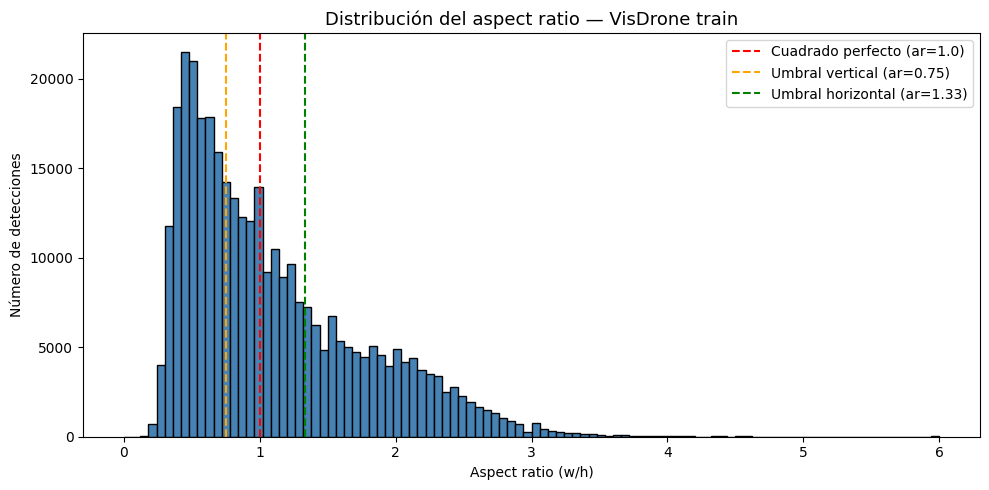

In [15]:
# ── Histograma global de aspect ratio ────────────────────────────────────────
fig,ax=plt.subplots(figsize=(10, 5))

# Limitar a rango útil para visualización (quitar outliers extremos)
ar_clipped=df["aspect_ratio"].clip(0, 6)

ax.hist(ar_clipped, bins=100, color="steelblue", edgecolor="black")

ax.axvline(1.0,  color="red",    linestyle="--", linewidth=1.5, label="Cuadrado perfecto (ar=1.0)")
ax.axvline(0.75, color="orange", linestyle="--", linewidth=1.5, label="Umbral vertical (ar=0.75)")
ax.axvline(1.33, color="green",  linestyle="--", linewidth=1.5, label="Umbral horizontal (ar=1.33)")

ax.set_title("Distribución del aspect ratio — VisDrone train", fontsize=13)
ax.set_xlabel("Aspect ratio (w/h)")
ax.set_ylabel("Número de detecciones")
ax.legend()

plt.tight_layout()
plt.savefig(output_dir / "05_aspect_ratio_global.png", dpi=150, bbox_inches="tight")
plt.show()

### Visualización 2: Aspect ratio por clase (boxplot)
Compara la forma típica de cada clase ordenada por mediana.

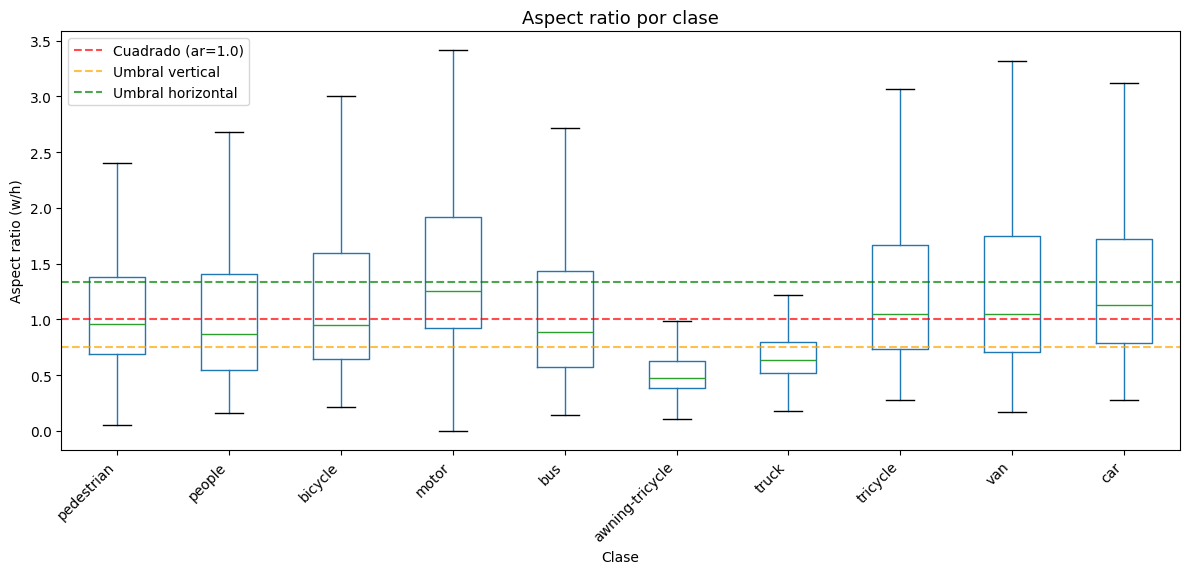

In [16]:
# ── Boxplot de aspect ratio por clase ────────────────────────────────────────
fig,ax=plt.subplots(figsize=(12, 6))

# Ordenar por mediana de aspect ratio
class_order_ar=df.groupby("class")["aspect_ratio"].median().sort_values().index

# Clip para visualización limpia (sin outliers extremos)
df_plot=df.copy()
df_plot["aspect_ratio"] = df_plot["aspect_ratio"].clip(0, 5)

df_plot.boxplot(
    column="aspect_ratio",
    by="class",
    ax=ax,
    grid=False,
    showfliers=False,
    positions=range(len(class_order_ar))
)

ax.set_xticklabels(class_order_ar, rotation=45, ha="right")
ax.axhline(1.0,  color="red",    linestyle="--", alpha=0.7, label="Cuadrado (ar=1.0)")
ax.axhline(0.75, color="orange", linestyle="--", alpha=0.7, label="Umbral vertical")
ax.axhline(1.33, color="green",  linestyle="--", alpha=0.7, label="Umbral horizontal")

ax.set_title("Aspect ratio por clase", fontsize=13)
ax.set_xlabel("Clase")
ax.set_ylabel("Aspect ratio (w/h)")
ax.legend()
plt.suptitle("")

plt.tight_layout()
plt.savefig(output_dir / "06_aspect_ratio_por_clase.png", dpi=150, bbox_inches="tight")
plt.show()

### Tabla: mediana de aspect ratio por clase
Valores de referencia de mediana de aspect ratio

In [17]:
#Tabla : estadisticas de aspect ratio por clase
ar_per_class=df.groupby("class")["aspect_ratio"].agg( #agg porque sirve para aplciar varias funciones
    mediana="median",
    media="mean",
    p25=lambda x:x.quantile(0.25), #el 25% de los objetos tienen aspect ratio menor a este valor
    p75=lambda x:x.quantile(0.75) #el 75% de los objetos tienen aspect raito menor a este valor
).round(3).sort_values("mediana")

print("Aspect ratio por clase (ordenado por mediana):")
ar_per_class

Aspect ratio por clase (ordenado por mediana):


,mediana,media,p25,p75
class,,,,
pedestrian,0.474,0.562,0.385,0.625
people,0.636,0.690,0.522,0.800
bicycle,0.867,1.023,0.548,1.405
motor,0.882,1.044,0.571,1.429
bus,0.947,1.194,0.648,1.594
awning-tricycle,0.957,1.072,0.692,1.378
truck,1.043,1.277,0.704,1.750
tricycle,1.047,1.221,0.729,1.667
van,1.125,1.270,0.789,1.722


In [18]:
#Exportar tablas a CSV
shape_summary.to_csv(tables_dir / "04_shape_summary.csv")
ar_per_class.to_csv(tables_dir  / "05_aspect_ratio_por_clase.csv")

## 5. Densidad de objetos por imagen

Analizamos cuántos objetos hay por imagen para confirmar la **alta densidad**
característica de VisDrone, uno de los retos centrales del dominio aéreo.

Una densidad alta implica mayor oclusión parcial entre objetos y mayor
dificultad para el modelo al separar detecciones cercanas.

### Métricas a calcular
- Distribución del número de objetos por imagen
- Media, mediana y percentiles de densidad
- Imágenes con densidad extrema (muy pocas y muchas detecciones)
- Densidad desglosada por clase

In [19]:
# Densidad de objetos por imagen

#Contar objetos por imagen
density=df.groupby("image").size().reset_index(name="n_objetos") # agrupa por imagen y cuenta objetos por imagen; reset_index lo convierte en DataFrame con columna "n_objetos"

print("Estadísticas de densidad (objetos por imagen):")
print(density["n_objetos"].describe().round(2))
print()
print(f"Media:{density['n_objetos'].mean():.1f} objetos/imagen")
print(f"Mediana:{density['n_objetos'].median():.1f} objetos/imagen")
print(f"Máximo:{density['n_objetos'].max()} objetos en una sola imagen")
print(f"Mínimo:{density['n_objetos'].min()} objetos en una sola imagen")
print()

# Clasificar por nivel de densidad
def density_level(n):
    if n <= 5:
        return "baja (1-5)"
    elif n <= 20:
        return "media (6-20)"
    elif n <= 50:
        return "alta (21-50)"
    else:
        return "muy alta (>50)"
    

density["nivel"]=density["n_objetos"].apply(density_level)

nivel_counts=density["nivel"].value_counts()
nivel_pct=(nivel_counts / len(density) * 100).round(2)

density_summary=pd.DataFrame({
    "imágenes" :nivel_counts,
    "porcentaje":nivel_pct
})

print("Distribución por nivel de densidad:")
density_summary

density_summary.to_csv(tables_dir / "06_densidad_niveles.csv")

Estadísticas de densidad (objetos por imagen):
count    6470.00
mean       53.04
std        43.84
min         1.00
25%        24.00
50%        42.00
75%        70.00
max       902.00
Name: n_objetos, dtype: float64

Media:53.0 objetos/imagen
Mediana:42.0 objetos/imagen
Máximo:902 objetos en una sola imagen
Mínimo:1 objetos en una sola imagen

Distribución por nivel de densidad:


### Visualización 1: Histograma de densidad
Distribución del número de objetos por imagen.

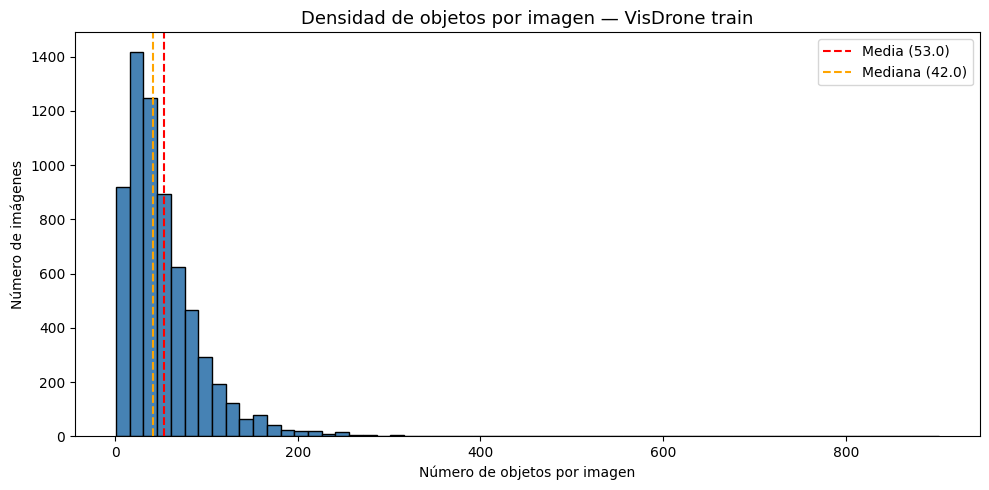

In [20]:
#Histograma de densidad
fig,ax=plt.subplots(figsize=(10,5))

ax.hist(density["n_objetos"], bins=60, color="steelblue", edgecolor="black")

# Líneas de referencia
ax.axvline(density["n_objetos"].mean(),   color="red",    linestyle="--",linewidth=1.5, label=f"Media ({density['n_objetos'].mean():.1f})")
ax.axvline(density["n_objetos"].median(), color="orange", linestyle="--",linewidth=1.5, label=f"Mediana ({density['n_objetos'].median():.1f})")

ax.set_title("Densidad de objetos por imagen — VisDrone train", fontsize=13)
ax.set_xlabel("Número de objetos por imagen")
ax.set_ylabel("Número de imágenes")
ax.legend()

plt.tight_layout()
plt.savefig(output_dir / "07_densidad_por_imagen.png", dpi=150, bbox_inches="tight")
plt.show()


### Visualización 2: Top 10 imágenes más densas
Las imágenes con más objetos representan el caso extremo
que el modelo debe ser capaz de manejar.

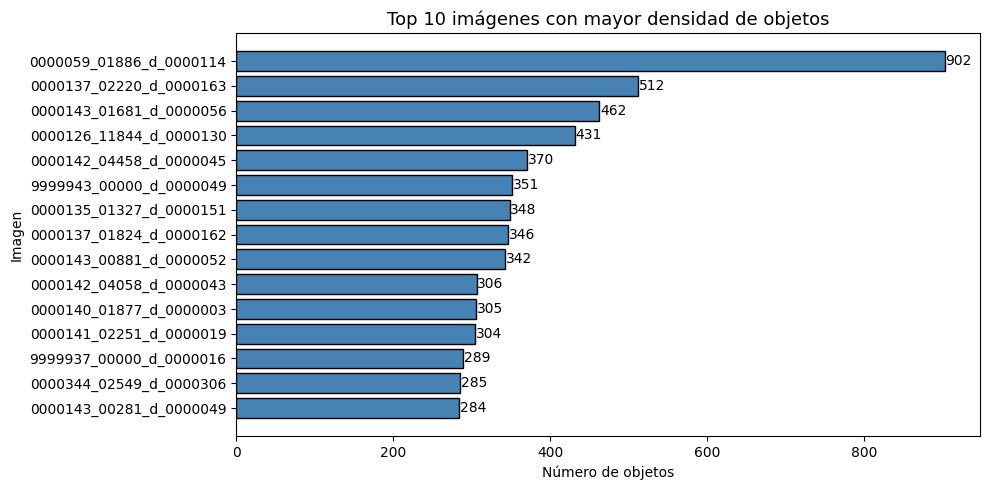

In [21]:
#TOP 10 imagenes mas densas
top10=density.nlargest(15,"n_objetos")[["image","n_objetos"]] #10 filas donde n_objetos sea mayor y solo seleccionamos image y n_objetos

fig, ax=plt.subplots(figsize=(10, 5))

ax.barh(top10["image"], top10["n_objetos"], color="steelblue", edgecolor="black")

for i, v in enumerate(top10["n_objetos"]):
    ax.text(v + 1, i, str(v), va="center", fontsize=10)

ax.set_title("Top 10 imágenes con mayor densidad de objetos", fontsize=13)
ax.set_xlabel("Número de objetos")
ax.set_ylabel("Imagen")
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(output_dir / "08_top10_densidad.png", dpi=150, bbox_inches="tight")
top10.to_csv(tables_dir / "08_top10_densidad.csv", index=False)
plt.show()

¿Qué clases tienden a aparecer en escenas más densas?

El valor de cada barra indica **qué tan llena está la imagen cuando aparece
esa clase**  no cuántos objetos de esa clase hay. Un valor de 104 en `bicycle`
significa que las imágenes donde aparece al menos una bicicleta tienen en promedio
104 objetos totales entre todas las clases.

Las clases con mayor densidad promedio enfrentan dos dificultades simultáneas:
tamaño reducido (small object) + alta oclusión por los objetos que las rodean.

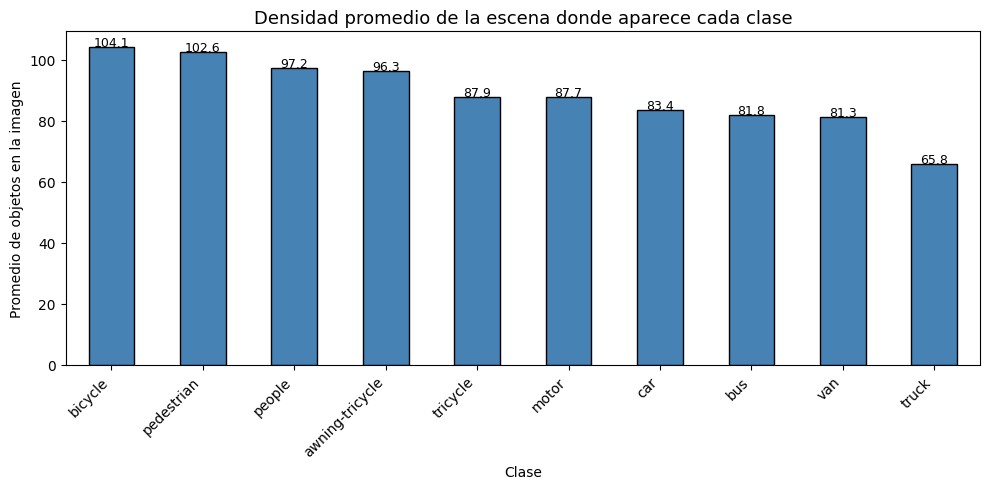

In [22]:
#Densidad promedio por clase

#Unir densidad con el dataframe original
df_density=df.merge(density[["image","n_objetos"]],on="image") #se une por medio donde image coincida de los dos dataframes

#Densidad promedio de la imagen donde aparece cada clase
density_per_class=df_density.groupby("class")["n_objetos"].mean().sort_values(ascending=False).round(1)

fig, ax=plt.subplots(figsize=(10, 5))

density_per_class.plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")

for i, v in enumerate(density_per_class.values):
    ax.text(i, v + 0.3, str(v), ha="center", fontsize=9)

ax.set_title("Densidad promedio de la escena donde aparece cada clase", fontsize=13)
ax.set_xlabel("Clase")
ax.set_ylabel("Promedio de objetos en la imagen")
ax.set_xticklabels(density_per_class.index, rotation=45, ha="right")

plt.tight_layout()
density_per_class.to_frame().to_csv(tables_dir / "07_densidad_por_clase.csv")
plt.savefig(output_dir / "09_densidad_por_clase.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Distribución de resoluciones de imagen

Analizamos las resoluciones del split train para determinar el tamaño
de entrada óptimo al entrenar los modelos.

Dado que el 60.5% de los objetos son **small objects** (área < 32² px),
comprimir las imágenes agresivamente eliminaría información crítica.
Este análisis justifica la elección de `imgsz` en el entrenamiento.

### Métricas a calcular
- Resoluciones únicas presentes en el dataset
- Resolución más común (moda)
- Distribución de ancho y alto de las imágenes

In [23]:
#Distribución de resoluciones de imagen

from PIL import Image

IMAGES_TRAIN=DATASET_ROOT/cfg["train"]

#Leer resolución de cada imagen
resolutions=[]
images_files=sorted(IMAGES_TRAIN.glob("*.jpg")) #tomar todas las imagenes (extension.jpg) y organizarlas alfabeticamente

print(f"Total de imagenes a leer: {len(images_files):,}")
print("Leyendo resoluciones...")

for img_path in images_files:
    with Image.open(img_path) as img:
        w,h=img.size
        resolutions.append({
            "image":img_path.stem, #sin extension
            "width":w,
            "height":h,
            "resolution":f"{w}x{h}"
        })

df_res=pd.DataFrame(resolutions)

print(f"Resoluciones únicas encontradas:{df_res['resolution'].unique()}")
print()
print("Distribución de resoluciones:")

res_counts=df_res["resolution"].value_counts()
res_pct=(res_counts/len(df_res)*100).round(2)

res_summary=pd.DataFrame({
    "imagenes":res_counts,
    "porcentajes":res_pct
})

print(res_summary)


Total de imagenes a leer: 6,471
Leyendo resoluciones...
Resoluciones únicas encontradas:<StringArray>
[  '960x540',  '1360x765', '1920x1080', '1916x1078',  '1344x756', '1389x1042',
 '1400x1050',  '1400x788', '1398x1048', '2000x1500',   '480x360']
Length: 11, dtype: str

Distribución de resoluciones:
            imagenes  porcentajes
resolution                       
1400x1050       2498        38.60
1400x788        1299        20.07
2000x1500        772        11.93
1360x765         743        11.48
1916x1078        537         8.30
1920x1080        339         5.24
960x540          250         3.86
1398x1048         30         0.46
1344x756           1         0.02
1389x1042          1         0.02
480x360            1         0.02


### Estadísticas de ancho y alto
Verificamos si hay variación en las dimensiones para decidir
si se necesita padding o redimensionado al entrenar.

In [24]:
#Estadisticas de ancho y alto

print("Estadisticas de ancho (px):")
print(df_res["width"].describe().round(0))
print()
print("Estadisticas de alto (px):")
print(df_res["height"].describe().round(0))
print()
print(f"Ancho mín/máx:{df_res['width'].min()} / {df_res['width'].max()} px")
print(f"Alto mín/máx:{df_res['height'].min()} / {df_res['height'].max()} px")
print(f"Resolución más común: {df_res['resolution'].mode()[0]}")

Estadisticas de ancho (px):
count    6471.0
mean     1520.0
std       270.0
min       480.0
25%      1400.0
50%      1400.0
75%      1916.0
max      2000.0
Name: width, dtype: float64

Estadisticas de alto (px):
count    6471.0
mean     1002.0
std       235.0
min       360.0
25%       788.0
50%      1050.0
75%      1078.0
max      1500.0
Name: height, dtype: float64

Ancho mín/máx:480 / 2000 px
Alto mín/máx:360 / 1500 px
Resolución más común: 1400x1050


### Visualización 1: Distribución de resoluciones
Gráfica de barras con las resoluciones más frecuentes del dataset.

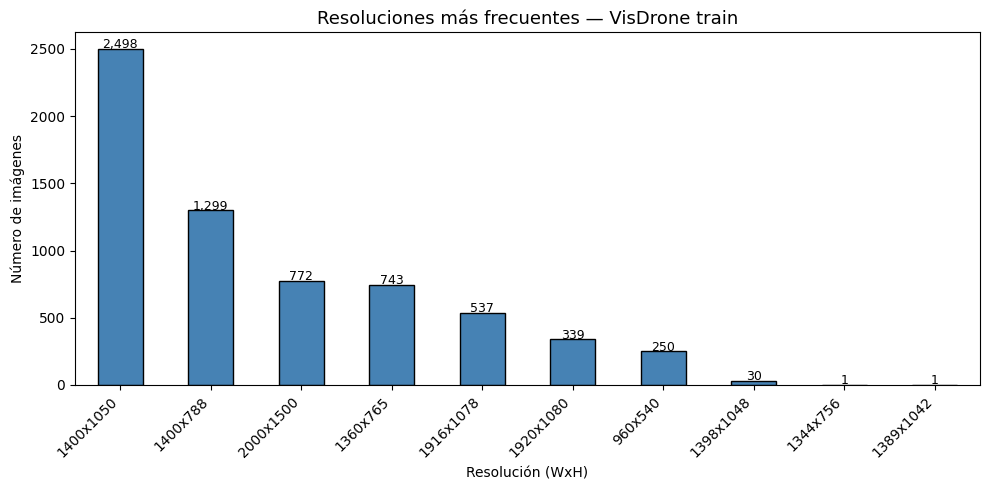

In [25]:
# Gráfica de resoluciones
fig,ax=plt.subplots(figsize=(10, 5))

res_counts.head(10).plot(kind="bar", ax=ax, color="steelblue", edgecolor="black")

for i, v in enumerate(res_counts.head(10).values):
    ax.text(i, v + 5, f"{v:,}", ha="center", fontsize=9)

ax.set_title("Resoluciones más frecuentes — VisDrone train", fontsize=13)
ax.set_xlabel("Resolución (WxH)")
ax.set_ylabel("Número de imágenes")
ax.set_xticklabels(res_counts.head(10).index, rotation=45, ha="right")

plt.tight_layout()
plt.savefig(output_dir/"10_resoluciones.png", dpi=150, bbox_inches="tight")
plt.show()

# Exportar tabla
res_summary.to_csv(tables_dir / "09_resoluciones.csv")

### Visualización 2: Scatter ancho vs alto
Para detectar si hay imágenes con proporciones inusuales
que podrían afectar el entrenamiento.

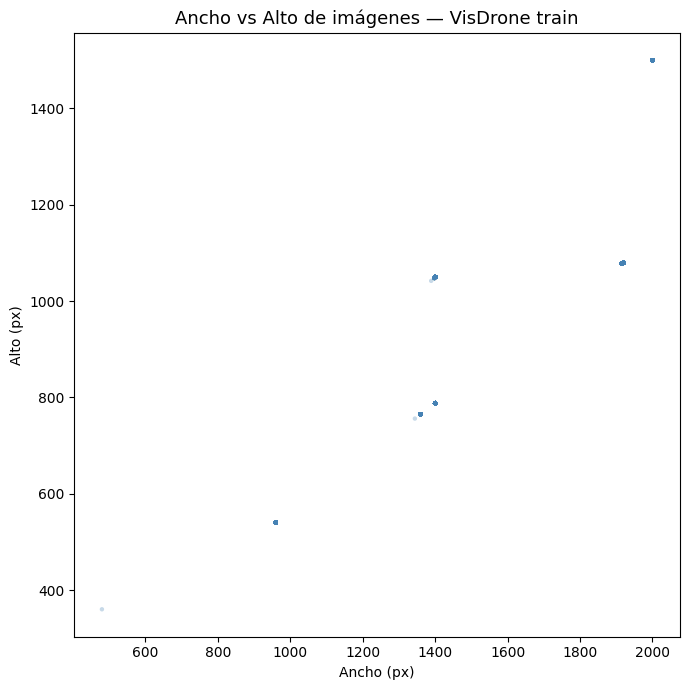

In [26]:
#Scatter ancho vs alto
fig,ax=plt.subplots(figsize=(7, 7))

ax.scatter(df_res["width"], df_res["height"],
           alpha=0.3, color="steelblue", edgecolors="none", s=10)

ax.set_title("Ancho vs Alto de imágenes — VisDrone train", fontsize=13)
ax.set_xlabel("Ancho (px)")
ax.set_ylabel("Alto (px)")

plt.tight_layout()
plt.savefig(output_dir/"11_scatter_resoluciones.png", dpi=150, bbox_inches="tight")
plt.show()

# Exportar tabla completa de resoluciones por imagen
df_res.to_csv(tables_dir/"10_resoluciones_por_imagen.csv", index=False)

## 7. Visualización de imágenes con bounding boxes

Verificamos visualmente que las anotaciones son correctas y obtenemos
ejemplos representativos del dataset.

Se seleccionan imágenes de distintos niveles de densidad para mostrar
la variedad de escenarios que el modelo deberá aprender a manejar:
escenas poco densas, densidad media y alta densidad con oclusión.

Cada clase se visualiza con un color distinto para identificar
la distribución espacial de objetos en la escena.

In [27]:
#Visualizacion de imagenes con bboxes

import cv2
import random

CLASS_COLORS={
    "pedestrian":(255,100,0),
    "people":(255,180,0),
    "bicycle":(0,200,0),
    "car":(0,100,255),
    "van": (0,200,255),
    "truck": (180,0,255),
    "tricycle": (255,0,180),
    "awning-tricycle": (0,255,180),
    "bus": (255,0,0),
    "motor" : (100,255,100),
}

print("Paleta de colores definida para las 10 clases.")
print("Clases:",list(CLASS_COLORS.keys()))

Paleta de colores definida para las 10 clases.
Clases: ['pedestrian', 'people', 'bicycle', 'car', 'van', 'truck', 'tricycle', 'awning-tricycle', 'bus', 'motor']


In [28]:
#Funcion para dibujar bboxes sobre una imagen
def draw_bboxes(img_name,df,images_dir,max_boxes=None):
    """
    Carga una imagen y dibuja sus bounding boxes con colores por clase

    Args:
        img_name:nombre de la imagen sin extension
        df:dataframe con las anotaciones
        images_dir:carpeta donde estan las imagenes
        max_boxes:limite de boxes a dibujar (None=todos)

    Returns:
        imagen con bboxes dibujados (numpy array BGR)    
    """

    #Cargar imagen
    img_path=images_dir/f"{img_name}.jpg"
    img=cv2.imread(str(img_path))
    img=cv2.cvtColor(img,cv2.COLOR_BGR2RGB) #convertir a RGB para matplolib

    #Filtras detecciones de esta imagen
    detecciones=df[df["image"]==img_name]

    if max_boxes:
        detecciones=detecciones.head(max_boxes)

    #Dibujar cada bbox
    for _,row in detecciones.iterrows(): #iteramos cada fila e ignoramos su indice (_)
        x,y,w,h=int(row["x"]),int(row["y"]),int(row["w"]),int(row["h"])
        color=CLASS_COLORS.get(row["class"],(255,255,255)) #toma la clase de la fila para devolver su color, sino devuelve por default 255,255,255 (blanco)
        clase=row["class"] #toma la clase

        #Rectangulo
        cv2.rectangle(img,(x,y),(x+w,y+h),color,2)

        #Etiqueta con fondo
        label=clase
        (tw,th),_=cv2.getTextSize(label,cv2.FONT_HERSHEY_SIMPLEX,0.4,1) #obtenemos textwidth y textheight y lo devuelve
        cv2.rectangle(img,(x,y-th-4),(x+tw+2,y),color,-1) #rectangulo de relleno en el texto por eso el -1, y a la esquina superior izquiera se le da un padding de 4 y a la esquina inferior derecha se le d aun padding de 2
        cv2.putText(img, label, (x + 1, y - 2),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (255, 255, 255), 1)
        
        return img

### Visualización 1: Muestra aleatoria de 6 imágenes
Selección aleatoria para ver la variedad general del dataset.

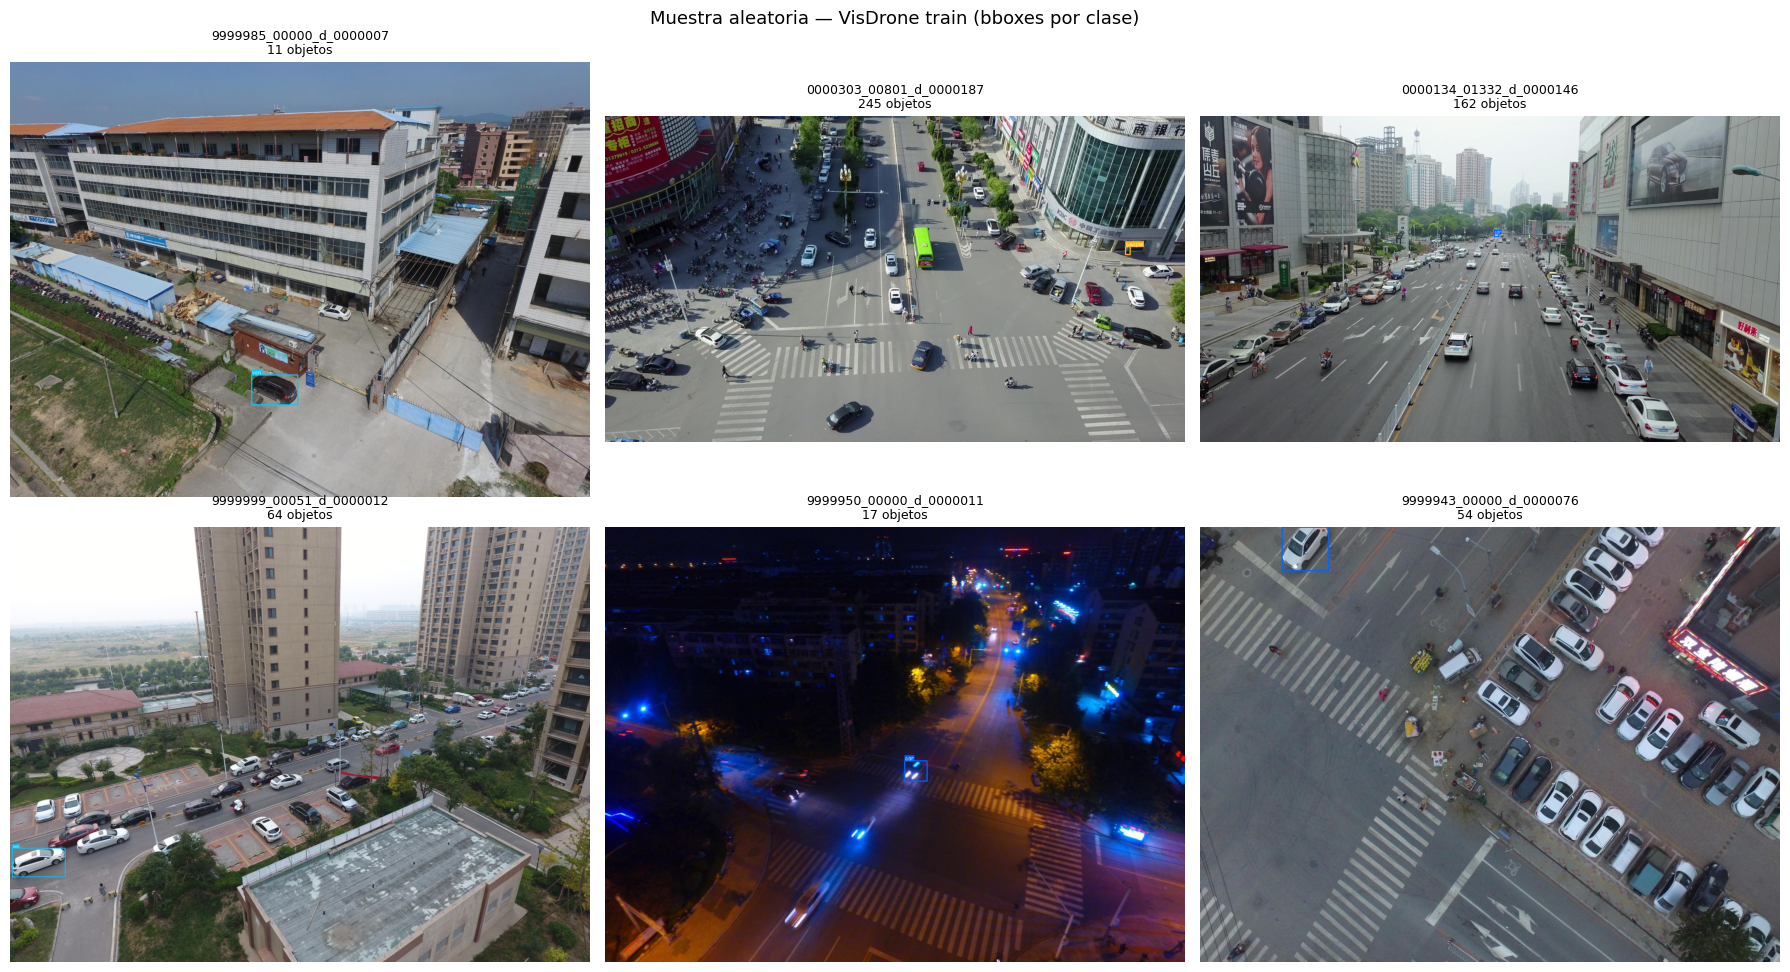

In [29]:
#Muestra aleatoria de 6 imagenes
random.seed(42) #para reproducibilidad
samples_images=random.sample(list(df["image"].unique()),6) #convertimos a lista para sample, usamos toma solo una imagen (unique), y toma 6 imagenes

fig,axes=plt.subplots(2,3,figsize=(18,10))
axes=axes.flatten()

for i, img_name in enumerate (samples_images):
    img_bbox=draw_bboxes(img_name,df,IMAGES_TRAIN)
    n_obj=len(df[df["image"]==img_name]) #obtenemos solo las filas correspondientes a esa imagen = n_objetos detectados
    axes[i].imshow(img_bbox)
    axes[i].set_title(f"{img_name}\n{n_obj} objetos",fontsize=9)
    axes[i].axis("off")

plt.suptitle("Muestra aleatoria — VisDrone train (bboxes por clase)", fontsize=13)
plt.tight_layout()
plt.savefig(output_dir / "12_muestra_aleatoria.png", dpi=150, bbox_inches="tight")
plt.show()

    


### Visualización 2: Imágenes por nivel de densidad
Comparamos una imagen de baja, media y alta densidad para
mostrar el rango de complejidad del dataset.

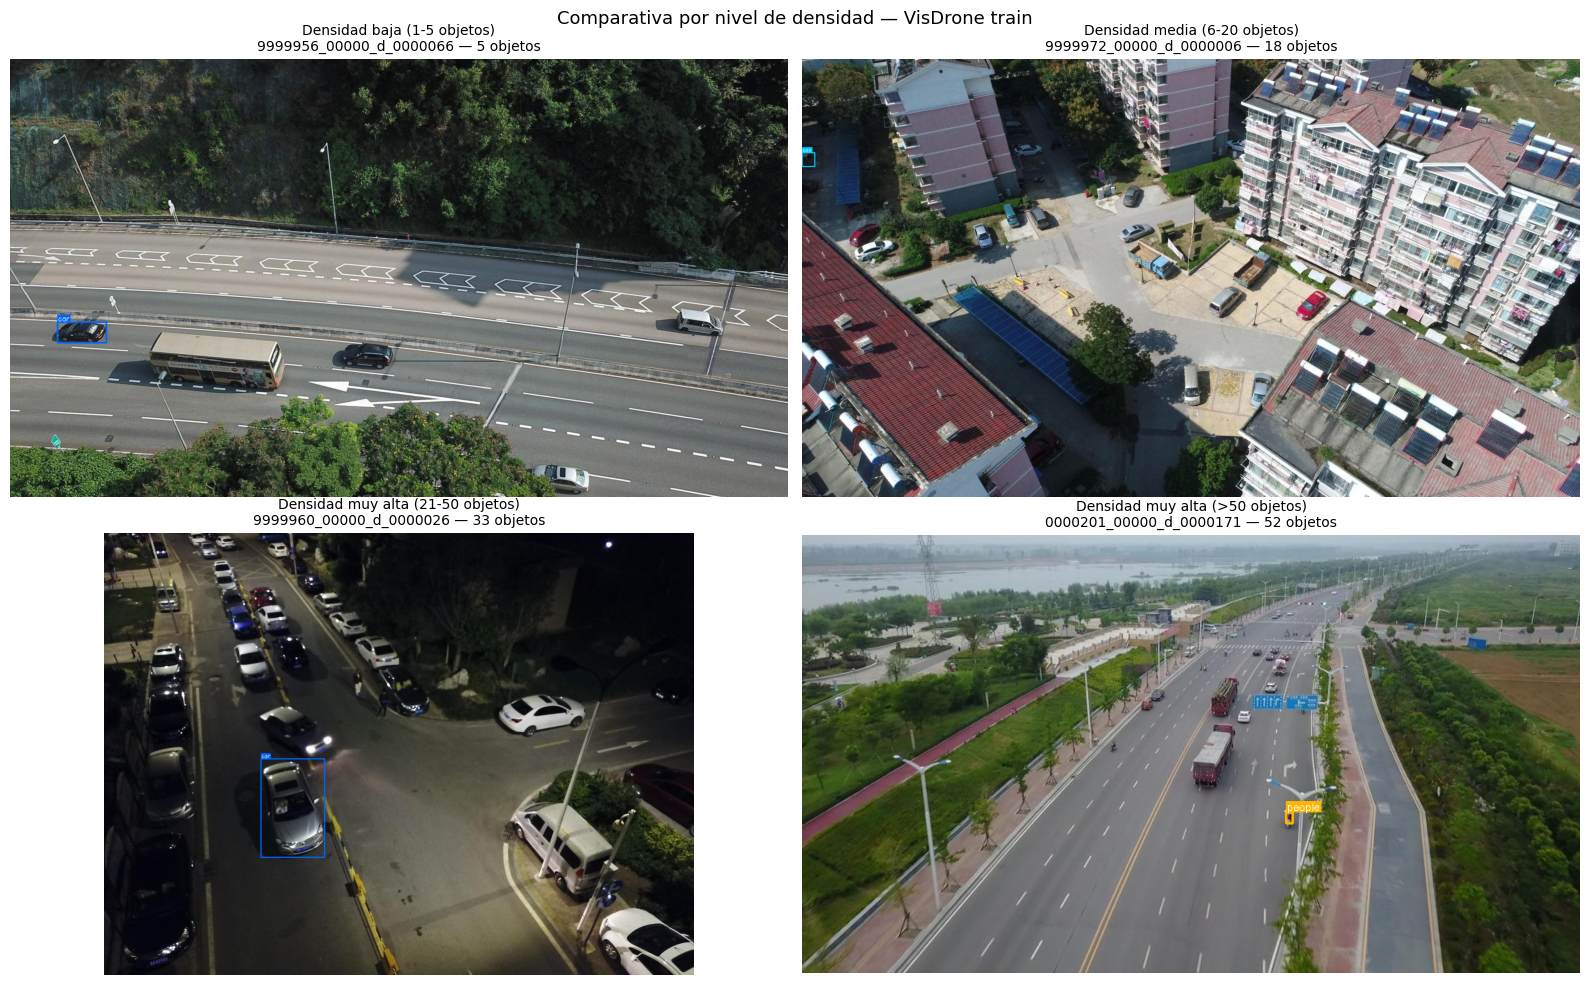

In [ ]:
#Una imagen por nivel de densidad

#Seleecionar una imagen representativa de cad anivel
baja=density[density["nivel"]=="baja (1-5)"].sample(1,random_state=42)["image"].values[0] #toma del df 1 fila aletoria (imagen) donde la densidad sea baja, toma solo la columna imagen, convierte a array numpy (["img_123.jpg"]) (un solo elemento por eso toma el [0])
media=density[density["nivel"]=="media (6-20)"].sample(1, random_state=42)["image"].values[0]
alta=density[density["nivel"]=="alta (21-50)"].sample(1, random_state=42)["image"].values[0]
muy_alta=density[density["nivel"]=="muy alta (>50)"].sample(1, random_state=42)["image"].values[0]

ejemplos=[
    (baja,"Densidad baja (1-5 objetos)"),
    (media,"Densidad media (6-20 objetos)"),
    (alta,"Densidad muy alta (21-50 objetos)"),
    (muy_alta,"Densidad muy alta (>50 objetos)"),
]

fig, axes=plt.subplots(2, 2, figsize=(16, 10))
axes=axes.flatten()

for i, (img_name, titulo) in enumerate(ejemplos): #obtiene el indice, nombre de la imagen y su titulo (densidad baja, densidad media...)
    img_bbox=draw_bboxes(img_name, df, IMAGES_TRAIN) # se llama a la funcion drawboxes
    n_obj=len(df[df["image"] == img_name]) #se obtiene el nuemero de objetos de la imagen
    axes[i].imshow(img_bbox)
    axes[i].set_title(f"{titulo}\n{img_name} — {n_obj} objetos", fontsize=10)
    axes[i].axis("off")

plt.suptitle("Comparativa por nivel de densidad — VisDrone train", fontsize=13)
plt.tight_layout()
plt.savefig(output_dir / "13_densidad_comparativa.png", dpi=150, bbox_inches="tight")
plt.show()

### Visualización 3: Zoom a objetos small
Recortamos una región de una imagen densa para mostrar
de cerca cómo se ven los small objects que el modelo debe detectar.

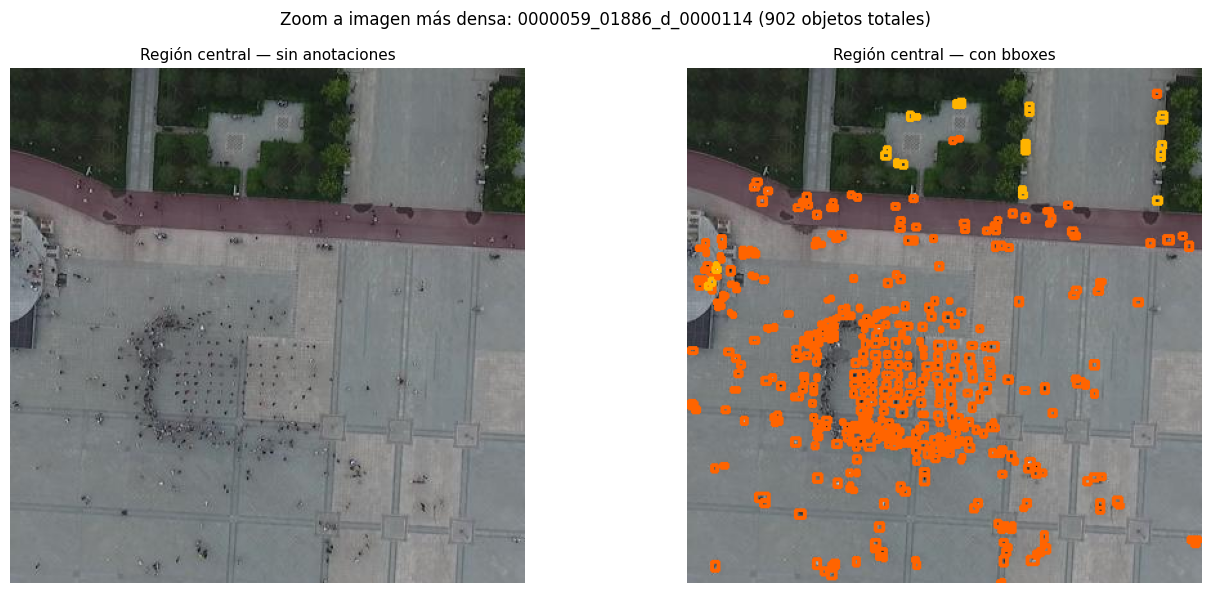

In [31]:
#ZOom a region densa

#Usar la imagen mas densa del dataset

img_name_top=density.nlargest(1,"n_objetos")["image"].values[0] #toma solo una imagen con los n_objetos mas grandes, obtiene su nombre y lo convierte a arraynumpy y accede al [0] porque solo hay un valor
img_path=IMAGES_TRAIN/f"{img_name_top}.jpg"
img_full=cv2.imread(str(img_path))
img_full=cv2.cvtColor (img_full,cv2.COLOR_BGR2RGB)

#Recortar region central (400x400 px)
h_img, w_img =img_full.shape[:2] #obtenemos solo h,w no el canal por eos :2
cx, cy=w_img//2,h_img//2 #obtenemos el centro
crop=img_full[cy-200:cy+200,cx-200:cx+200] #pixal inical y final en y , y pixel incial y final en x (obtenemos el cuadro central de 400x400) esto porque el centor tiene a tener mas objetos que los bordes

# Dibujar bboxes en el recorte
detecciones=df[df["image"]==img_name_top]
crop_bbox=crop.copy()

for _,row in detecciones.iterrows():
    x, y, w, h=int(row["x"]), int(row["y"]), int(row["w"]), int(row["h"])
    # Ajustar coordenadas al recorte
    x_crop=x-(cx - 200)
    y_crop=y-(cy - 200)
    if 0 <=x_crop<400 and 0<=y_crop<400:
        color=CLASS_COLORS.get(row["class"], (255, 255, 255))
        cv2.rectangle(crop_bbox,
                      (x_crop, y_crop),
                      (x_crop + w, y_crop + h),
                      color, 2)

fig, axes=plt.subplots(1, 2, figsize=(14, 6))
axes[0].imshow(crop)
axes[0].set_title("Región central — sin anotaciones", fontsize=11)
axes[0].axis("off")
axes[1].imshow(crop_bbox)
axes[1].set_title("Región central — con bboxes", fontsize=11)
axes[1].axis("off")

n_obj = len(detecciones)
plt.suptitle(f"Zoom a imagen más densa: {img_name_top} ({n_obj} objetos totales)",
             fontsize=12)
plt.tight_layout()
plt.savefig(output_dir / "14_zoom_small_objects.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Análisis de Truncación y Oclusión

La **truncación** indica si un objeto está cortado por el borde de la imagen,
mientras que la **oclusión** indica si está tapado por otro objeto.

Estos factores combinados con la alta proporción de small objects representan
los principales retos de robustez del dataset.

### Valores en VisDrone
**Truncación:**
- 0 = objeto completo dentro del encuadre
- 1 = objeto parcialmente fuera del encuadre (truncado)

**Oclusión:**
- 0 = sin oclusión
- 1 = oclusión parcial (1%–50% tapado)
- 2 = oclusión pesada (>50% tapado)

In [32]:
# Distribución de truncación
trunc_counts=df["truncation"].value_counts().sort_index()
trunc_pct =(trunc_counts / len(df) * 100).round(2)
trunc_summary=pd.DataFrame({
    "detecciones": trunc_counts,
    "porcentaje" : trunc_pct
})
trunc_summary.index=["completo (0)", "truncado (1)"]

# Distribución de oclusión
occl_counts=df["occlusion"].value_counts().sort_index()
occl_pct=(occl_counts / len(df) * 100).round(2)
occl_summary=pd.DataFrame({
    "detecciones":occl_counts,
    "porcentaje":occl_pct
})
occl_summary.index=["sin oclusión (0)", "oclusión parcial (1)", "oclusión pesada (2)"]

print("Truncación")
print(trunc_summary)
print()
print("Oclusión")
print(occl_summary)

Truncación
              detecciones  porcentaje
completo (0)       329800        96.1
truncado (1)        13371         3.9

Oclusión
                      detecciones  porcentaje
sin oclusión (0)           167277       48.74
oclusión parcial (1)       142242       41.45
oclusión pesada (2)         33652        9.81


### Visualización 1: Distribución de truncación y oclusión
Gráficas de barras lado a lado para comparar ambas distribuciones.

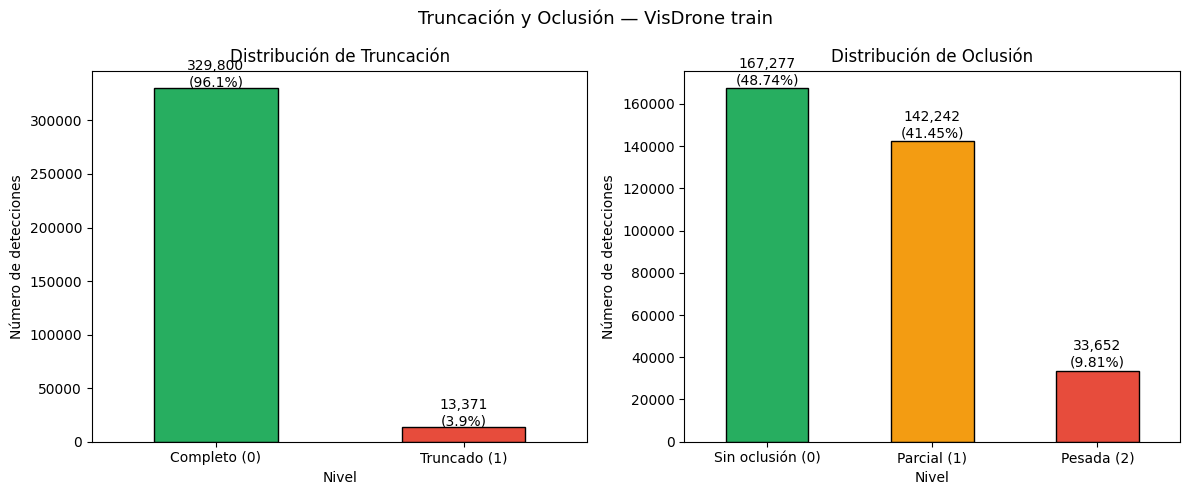

In [33]:
#Gráficas de truncación y oclusión
fig, axes=plt.subplots(1, 2, figsize=(12, 5))

# Truncación
colors_trunc=["#27ae60", "#e74c3c"]
trunc_counts.plot(kind="bar", ax=axes[0], color=colors_trunc, edgecolor="black")
axes[0].set_title("Distribución de Truncación", fontsize=12)
axes[0].set_xlabel("Nivel")
axes[0].set_ylabel("Número de detecciones")
axes[0].set_xticklabels(["Completo (0)", "Truncado (1)"], rotation=0)
for i, v in enumerate(trunc_counts.values):
    axes[0].text(i, v + 2000, f"{v:,}\n({trunc_pct.iloc[i]}%)",
                 ha="center", fontsize=10)

# Oclusión
colors_occl=["#27ae60", "#f39c12", "#e74c3c"]
occl_counts.plot(kind="bar", ax=axes[1], color=colors_occl, edgecolor="black")
axes[1].set_title("Distribución de Oclusión", fontsize=12)
axes[1].set_xlabel("Nivel")
axes[1].set_ylabel("Número de detecciones")
axes[1].set_xticklabels(["Sin oclusión (0)", "Parcial (1)", "Pesada (2)"], rotation=0)
for i, v in enumerate(occl_counts.values):
    axes[1].text(i, v + 2000, f"{v:,}\n({occl_pct.iloc[i]}%)",
                 ha="center", fontsize=10)

plt.suptitle("Truncación y Oclusión — VisDrone train", fontsize=13)
plt.tight_layout()
plt.savefig(output_dir / "15_truncacion_oclusion.png", dpi=150, bbox_inches="tight")
plt.show()

# Exportar tablas
trunc_summary.to_csv(tables_dir / "11_truncacion.csv")
occl_summary.to_csv(tables_dir  / "12_oclusion.csv")

### Visualización 2: Truncación y oclusión por clase
¿Qué clases sufren más truncación y oclusión?

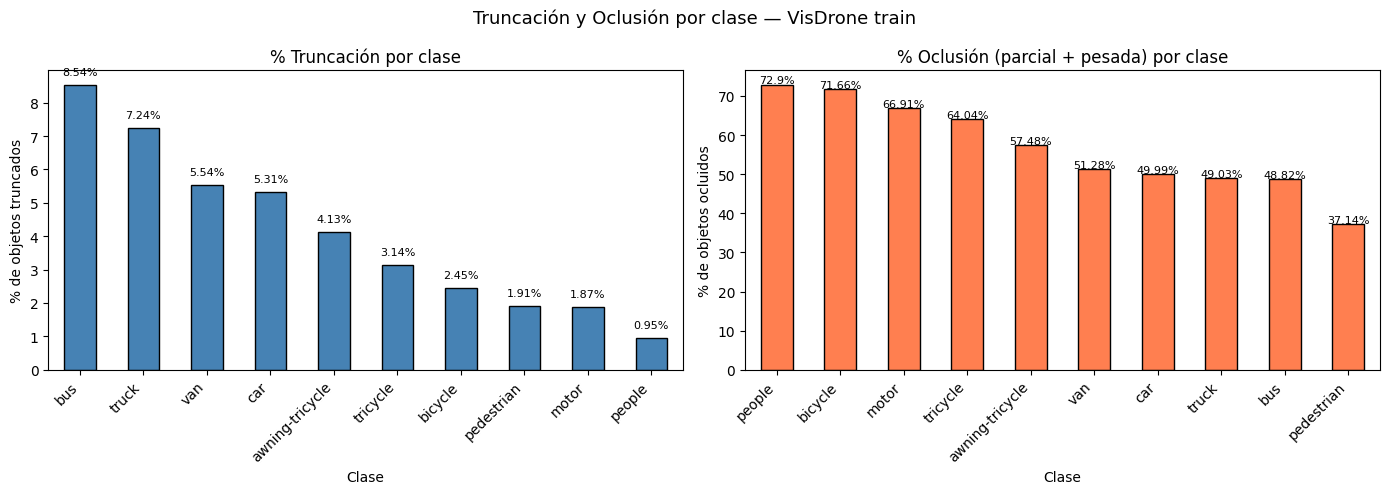

In [34]:
# Truncación y oclusión por clase

# % de truncados por clase
trunc_class=df.groupby("class")["truncation"].mean() * 100
trunc_class=trunc_class.sort_values(ascending=False).round(2)

# % de ocluidos (parcial + pesada) por clase
occl_class=(df.groupby("class")["occlusion"]
               .apply(lambda x: (x > 0).mean()) * 100
              ).sort_values(ascending=False).round(2)

fig, axes=plt.subplots(1, 2, figsize=(14, 5))

# Truncación por clase
trunc_class.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("% Truncación por clase", fontsize=12)
axes[0].set_xlabel("Clase")
axes[0].set_ylabel("% de objetos truncados")
axes[0].set_xticklabels(trunc_class.index, rotation=45, ha="right")
for i, v in enumerate(trunc_class.values):
    axes[0].text(i, v + 0.3, f"{v}%", ha="center", fontsize=8)

# Oclusión por clase
occl_class.plot(kind="bar", ax=axes[1], color="coral", edgecolor="black")
axes[1].set_title("% Oclusión (parcial + pesada) por clase", fontsize=12)
axes[1].set_xlabel("Clase")
axes[1].set_ylabel("% de objetos ocluidos")
axes[1].set_xticklabels(occl_class.index, rotation=45, ha="right")
for i, v in enumerate(occl_class.values):
    axes[1].text(i, v + 0.3, f"{v}%", ha="center", fontsize=8)

plt.suptitle("Truncación y Oclusión por clase — VisDrone train", fontsize=13)
plt.tight_layout()
plt.savefig(output_dir / "16_truncacion_oclusion_por_clase.png", dpi=150, bbox_inches="tight")
plt.show()

# Exportar
trunc_class.to_frame().to_csv(tables_dir / "13_truncacion_por_clase.csv")
occl_class.to_frame().to_csv(tables_dir  / "14_oclusion_por_clase.csv")

### Visualización 3: Combinación truncación + oclusión
Análisis de objetos que sufren ambos problemas simultáneamente
el caso más difícil para el modelo.

Distribución de dificultad combinada:
                    detecciones  porcentaje
dificultad                                 
solo ocluido             170978       49.82
sin problemas            158822       46.28
solo truncado              8455        2.46
truncado + ocluido         4916        1.43

Objetos sin ningún problema :46.28%
Objetos con algún problema:53.72%


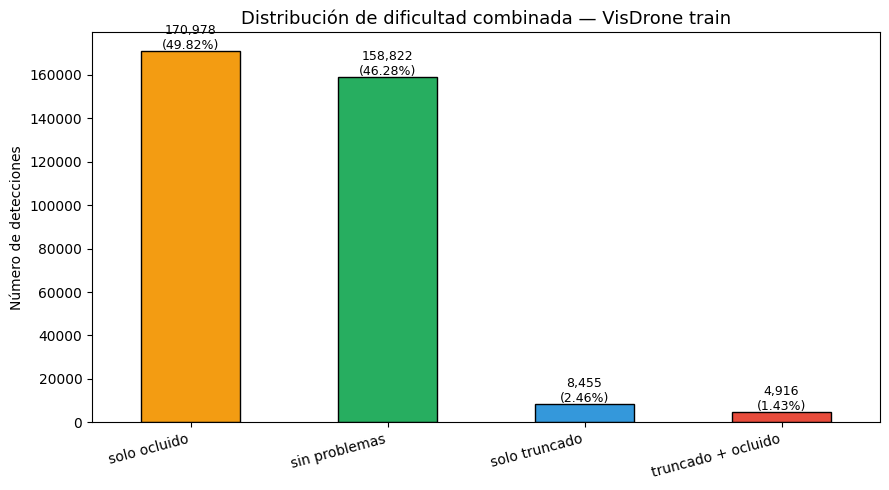

In [35]:
# ── Casos combinados: truncación + oclusión ───────────────────────────────────

# Categorizar cada detección
def dificultad(row):
    if row["truncation"]==1 and row["occlusion"] > 0:
        return "truncado + ocluido"
    elif row["truncation"]==1:
        return "solo truncado"
    elif row["occlusion"]>0:
        return "solo ocluido"
    else:
        return "sin problemas"

df["dificultad"]=df.apply(dificultad, axis=1)

dif_counts=df["dificultad"].value_counts()
dif_pct=(dif_counts / len(df) * 100).round(2)

dif_summary=pd.DataFrame({
    "detecciones":dif_counts,
    "porcentaje":dif_pct
})

print("Distribución de dificultad combinada:")
print(dif_summary)
print()
print(f"Objetos sin ningún problema :{dif_summary.loc['sin problemas', 'porcentaje']}%")
print(f"Objetos con algún problema:{100 - dif_summary.loc['sin problemas', 'porcentaje']:.2f}%")

# Gráfica
fig, ax = plt.subplots(figsize=(9, 5))
colors_dif = {
    "sin problemas":"#27ae60",
    "solo ocluido":"#f39c12",
    "solo truncado":"#3498db",
    "truncado + ocluido":"#e74c3c"
}
colors_ordered = [colors_dif[k] for k in dif_counts.index]
dif_counts.plot(kind="bar", ax=ax, color=colors_ordered, edgecolor="black")

for i, v in enumerate(dif_counts.values):
    ax.text(i, v + 1000, f"{v:,}\n({dif_pct.iloc[i]}%)", ha="center", fontsize=9)

ax.set_title("Distribución de dificultad combinada — VisDrone train", fontsize=13)
ax.set_xlabel("")
ax.set_ylabel("Número de detecciones")
ax.set_xticklabels(dif_counts.index, rotation=15, ha="right")

plt.tight_layout()
plt.savefig(output_dir / "17_dificultad_combinada.png", dpi=150, bbox_inches="tight")
plt.show()

dif_summary.to_csv(tables_dir / "15_dificultad_combinada.csv")

---

## Resumen de hallazgos EDA VisDrone-DET2019

El análisis exploratorio reveló los siguientes hallazgos clave que guían
las decisiones de preprocesamiento, augmentación y entrenamiento:

| Hallazgo | Dato | Decisión técnica |
|----------|------|-----------------|
| Desbalance de clases | Ratio 44.7x (car vs awning-tricycle) | copy-paste dirigido + class weighting |
| Small objects | 60.5% con área < 32² px · mediana 26×26 px | imgsz=1280 en entrenamiento |
| Alta densidad | Media 53 obj/imagen · máximo 902 obj | mosaic augmentation |
| Aspect ratio distinto a COCO | car mediana 1.25 vs ~3.0 en COCO | recalcular anchors para VisDrone |
| Resoluciones variadas | 11 resoluciones · media 1520×1002 px | letterboxing automático de YOLO |
| Oclusión severa | 51.26% con algún nivel de oclusión | copy-paste + mixup |

### Conclusión
VisDrone-DET2019 presenta tres factores de dificultad simultáneos:
**small objects**, **alta densidad** y **oclusión severa**, combinados con
un **desbalance de clases de 44.7x**. Estos hallazgos justifican
experimentalmente cada decisión de la estrategia de preprocesamiento
y augmentación definida.